In [1]:
%%capture
%pip install -q scikit-learn==1.4.2 imbalanced-learn==0.12.3 xgboost==2.1.1

# Credit Card Fraud Detection — Practical Modeling and Threshold Tuning

> **TL;DR:** A practical fraud detection workflow using time-aware evaluation, calibrated models, and threshold tuning.

## Overview

This notebook explores credit card fraud detection using a practical machine learning workflow.

The goal is not just to train a model, but to understand how different models, calibration, and decision thresholds affect real fraud detection performance.

Because fraud cases are rare, accuracy is not enough. We focus on metrics such as AUPRC, recall, precision, calibration quality, and simple cost-based operating points.

## Approach

- **Dataset:** credit card transactions with severe class imbalance.
- **Split:** time-ordered train, validation, and test windows to avoid look-ahead leakage.
- **Feature Engineering:** transaction amount transforms and simple time-based proxy features.
- **Models:** Logistic Regression, Random Forest, and XGBoost.
- **Calibration:** probability calibration to make model scores more useful for threshold decisions.
- **Decision Tuning:** validation-selected thresholds for precision-first and cost-aware operating points.

## Evaluation Focus

AUPRC is used as the main metric because fraud detection is highly imbalanced. ROC-AUC is still reported, but it can look overly optimistic when the negative class dominates.

Thresholds are selected on the validation set and then reported on the held-out test set. This keeps the final test results unbiased.

Cost values such as false-negative and false-positive costs are illustrative. In a real setting, they should be replaced with business-specific assumptions.

## What You’ll Get

- A leakage-aware evaluation setup.
- Baseline and tree-based fraud models.
- Calibrated probability scores.
- Precision-first and cost-aware threshold analysis.
- Final operating-point recommendation with limitations.

# Import Libraries

In [2]:
import warnings, os, json, math, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score, confusion_matrix, brier_score_loss
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_context("notebook")
plt.rcParams["figure.figsize"]=(10,5)

SEED = 42
np.random.seed(SEED)

# Business cost assumptions (tune as needed)
COST_FP = 5.0     # investigation cost per false alert
COST_FN = 200.0   # average loss per missed fraud



## Load Data

In [3]:
df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')


## Initial Data Exploration

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

In [6]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.369007e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.500885e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.426963e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
print("Shape:", df.shape)


Shape: (284807, 31)


# Data Cleaning

In [8]:
print(df.columns.tolist())


['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## Check missing values


In [9]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [10]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)


Duplicates: 1081


In [11]:
print("Shape after duplicate removal:", df.shape)

print("\nTarget counts after cleaning:")
print(df["Class"].value_counts())

print("\nTarget distribution after cleaning (%):")
print(df["Class"].value_counts(normalize=True).mul(100).round(4))

Shape after duplicate removal: (283726, 31)

Target counts after cleaning:
Class
0    283253
1       473
Name: count, dtype: int64

Target distribution after cleaning (%):
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


# Feature Engineering

In [12]:
# Time-derived proxies (Time = seconds-from-start, not real timestamps)

df['Hour_from_start_mod24'] = ((df['Time'] // 3600) % 24).astype(int)
df['is_night_proxy'] = df['Hour_from_start_mod24'].isin([22,23,0,1,2,3,4,5]).astype(int)
df['is_business_hours_proxy'] = df['Hour_from_start_mod24'].between(9,17).astype(int)

df['_log_amount'] = np.log1p(df['Amount'])


features = [c for c in df.columns if c.startswith("V")] + [
    'Amount','_log_amount',
    'Hour_from_start_mod24','is_night_proxy','is_business_hours_proxy'
]
target = "Class"



# Exploratory Data Analysis (EDA)

# Imbalance + Pie

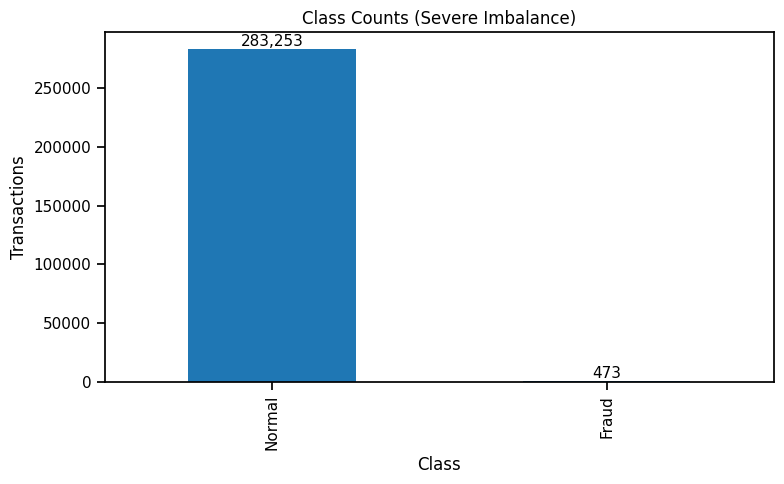

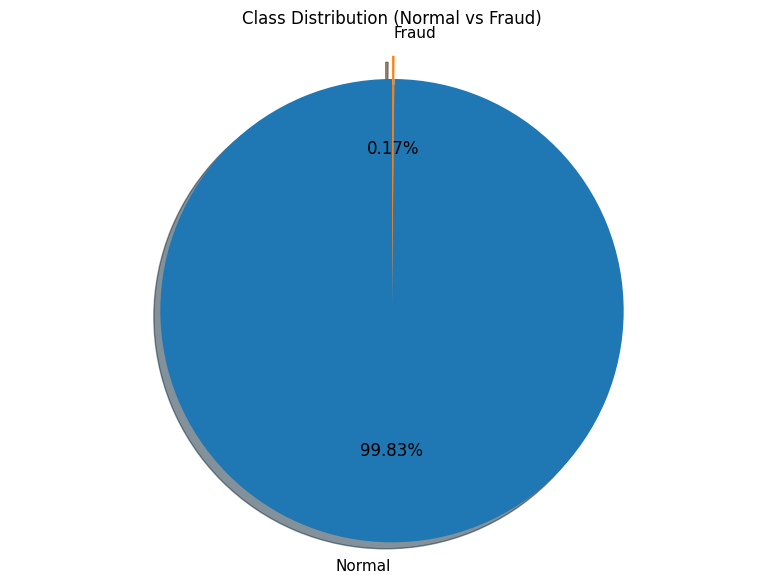

In [13]:
counts = df['Class'].value_counts().rename({0:'Normal', 1:'Fraud'})
fig, ax = plt.subplots(figsize=(8,5))
counts.plot(kind='bar', ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=11)
ax.set_title('Class Counts (Severe Imbalance)')
ax.set_ylabel('Transactions'); ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

# pie chart
fig, ax = plt.subplots(figsize=(8,6))
ax.pie(counts.values, labels=counts.index, autopct='%1.2f%%', startangle=90, explode=[0,0.1], shadow=True)
ax.set_title('Class Distribution (Normal vs Fraud)')
ax.axis('equal')
plt.tight_layout()
plt.show()


## Amount distribution

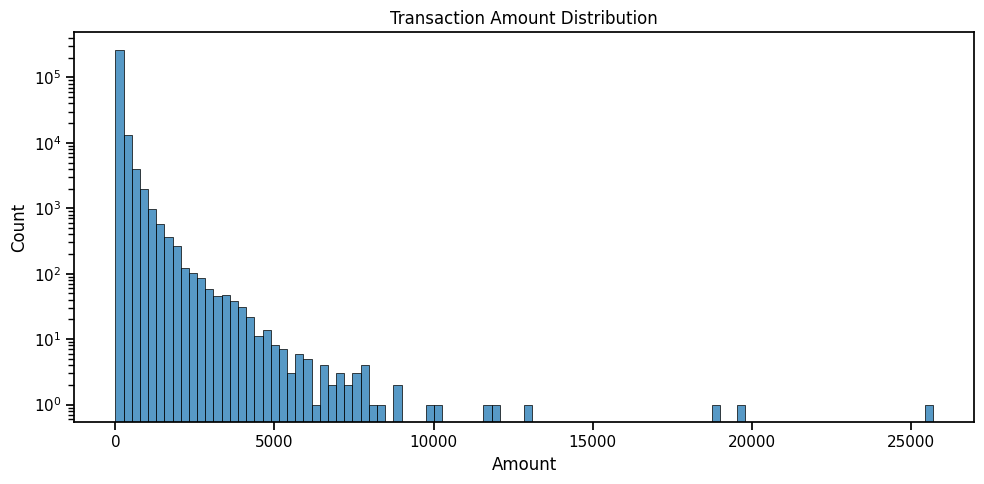

In [14]:
sns.histplot(df["Amount"], bins=100, log_scale=(False, True))
plt.title("Transaction Amount Distribution")
plt.tight_layout()
plt.show()

## log1p(Amount) — Class Separation

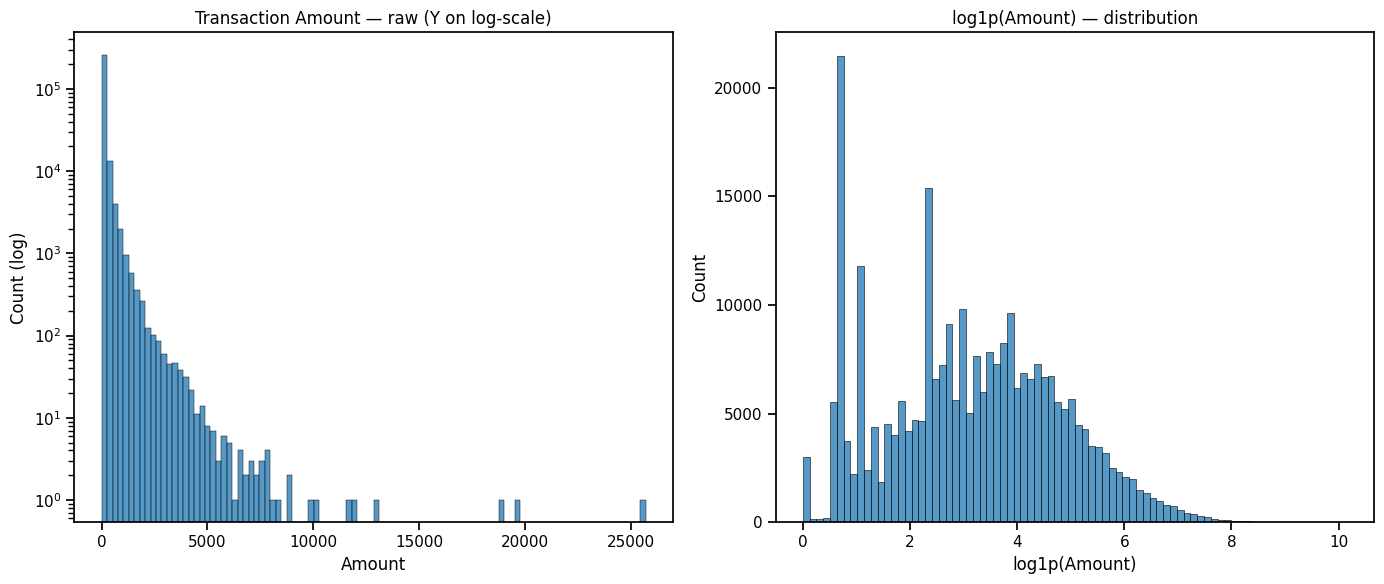

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw amount, log-scaled Y
sns.histplot(df["Amount"], bins=100, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Transaction Amount — raw (Y on log-scale)")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count (log)")

# Log-transformed feature on X
sns.histplot(df["_log_amount"], bins=80, ax=axes[1])
axes[1].set_title("log1p(Amount) — distribution")
axes[1].set_xlabel("log1p(Amount)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Left: “Raw amount with a logarithmic Y-axis to reveal the long tail of transaction counts without altering the original magnitude on X.”

### Right: “Distribution of log1p(Amount). The log transform reduces skewness and makes patterns easier to model and compare.”

## Fraud Rate by Hour-from-Start Proxy

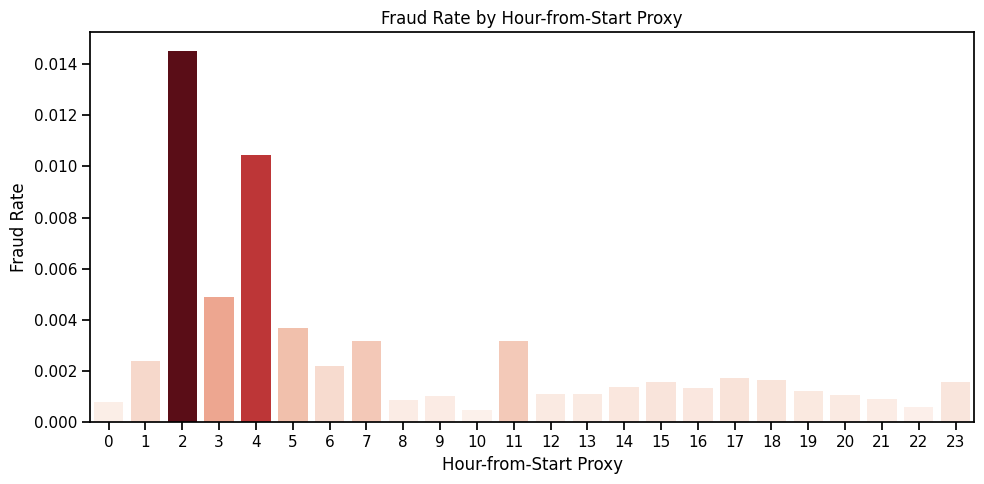

In [16]:
fraud_by_hour = df.groupby("Hour_from_start_mod24")["Class"].mean()

cmap = sns.color_palette("Reds", as_cmap=True)
vals = (fraud_by_hour / fraud_by_hour.max()).values
pal = [cmap(v) for v in vals]

sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, palette=pal)
plt.title("Fraud Rate by Hour-from-Start Proxy")
plt.xlabel("Hour-from-Start Proxy")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

## Transactions by Hour-from-Start Proxy

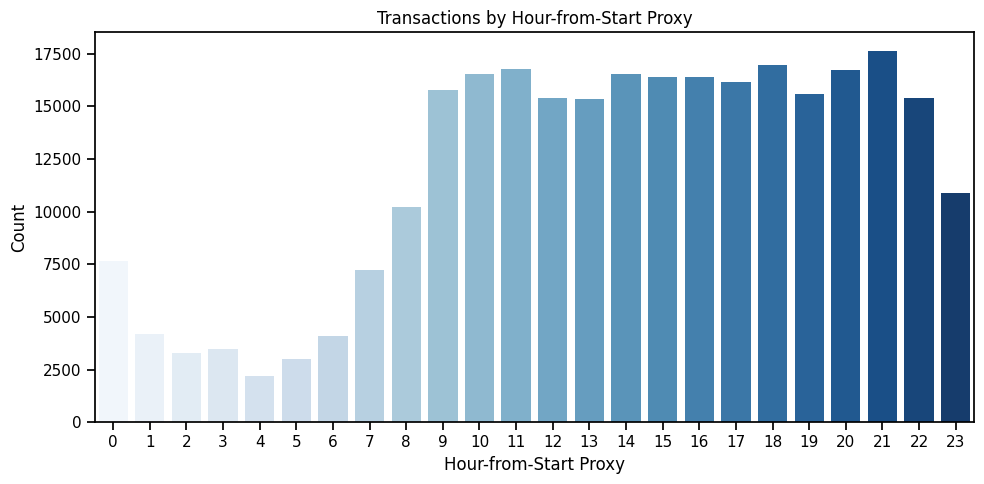

In [17]:
tx_by_hour = df.groupby("Hour_from_start_mod24")[target].count()
sns.barplot(x=tx_by_hour.index, y=tx_by_hour.values, palette='Blues')
plt.xlabel("Hour-from-Start Proxy")
plt.ylabel("Count")
plt.title("Transactions by Hour-from-Start Proxy")
plt.tight_layout()
plt.show()

## Boxplot: Amount by Class

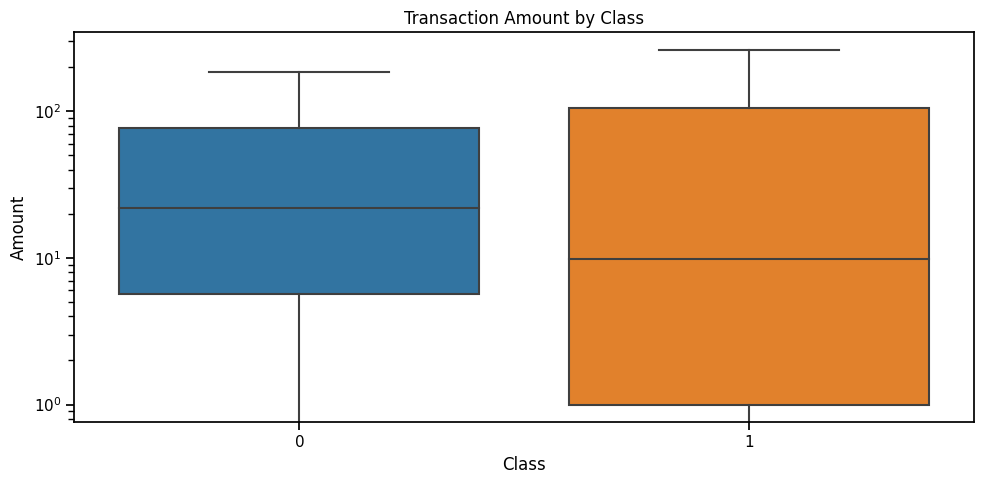

In [18]:
sns.boxplot(x= "Class", y="Amount" , data=df , showfliers=False)
plt.yscale("log")
plt.title("Transaction Amount by Class")
plt.tight_layout()
plt.show()

## Amount deciles vs fraud rate

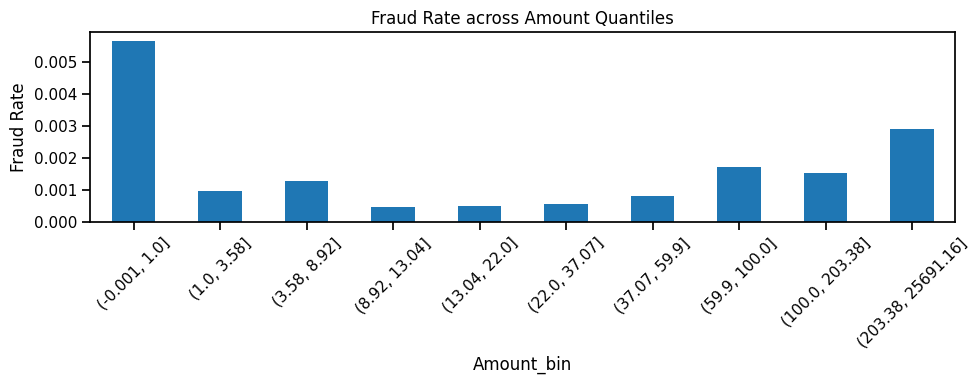

In [19]:
df["Amount_bin"] = pd.qcut(df["Amount"], q=10, duplicates="drop")
fraud_rate_bins = df.groupby("Amount_bin")["Class"].mean()
fraud_rate_bins.plot(kind="bar", figsize=(10,4))
plt.title("Fraud Rate across Amount Quantiles")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Correlation matrix 

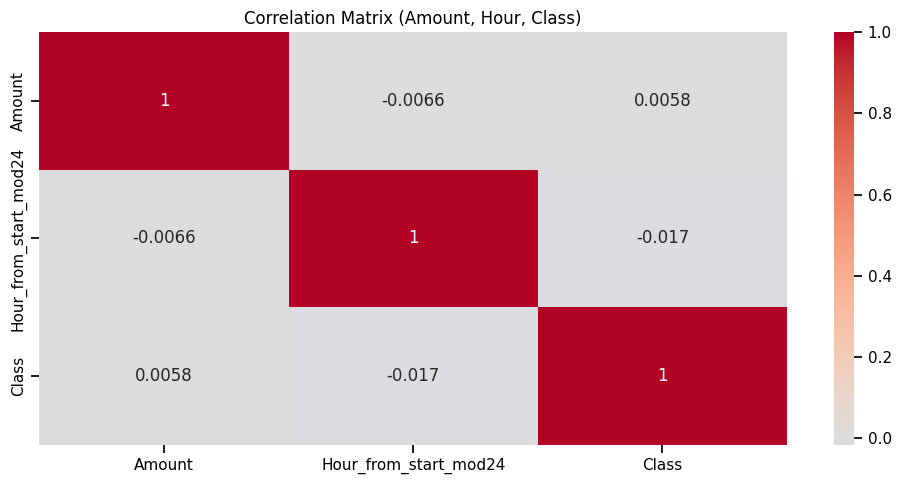

In [20]:
sns.heatmap(df[["Amount","Hour_from_start_mod24","Class"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Amount, Hour, Class)")
plt.tight_layout()
plt.show()


## Time Segment Proxies (Morning / Afternoon / Evening / Night)

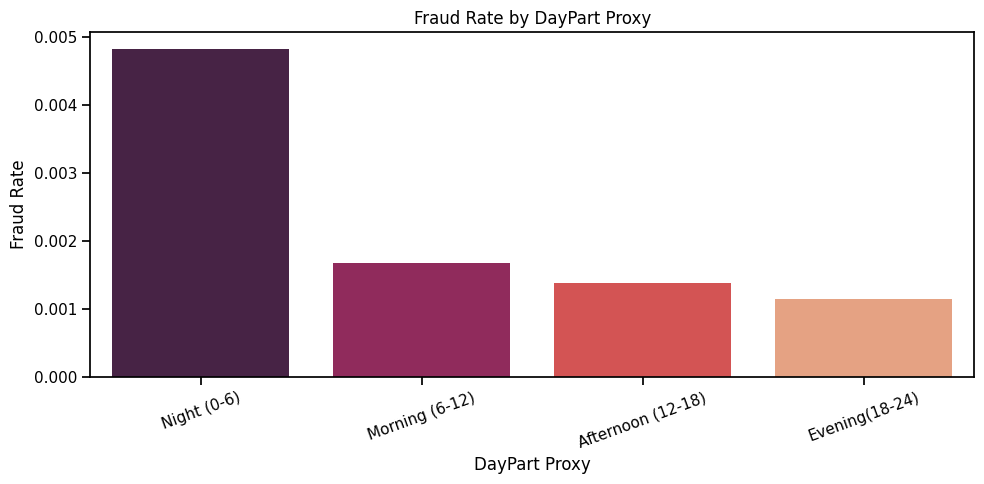

In [21]:
bins   = [0,6,12,18,24]
labels = ["Night (0-6)", "Morning (6-12)", "Afternoon (12-18)", "Evening(18-24)"]
df["DayPart"] = pd.cut(df["Hour_from_start_mod24"], bins=bins, labels=labels, right=False, include_lowest=True)


fraud_by_part  = df.groupby("DayPart")["Class"].mean().reindex(labels)

sns.barplot(x=fraud_by_part.index, y=fraud_by_part.values, palette="rocket")
plt.xticks(rotation=20)
plt.title("Fraud Rate by DayPart Proxy")
plt.xlabel("DayPart Proxy")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

## Bar View for Hour-from-Start Proxy Fraud Rate

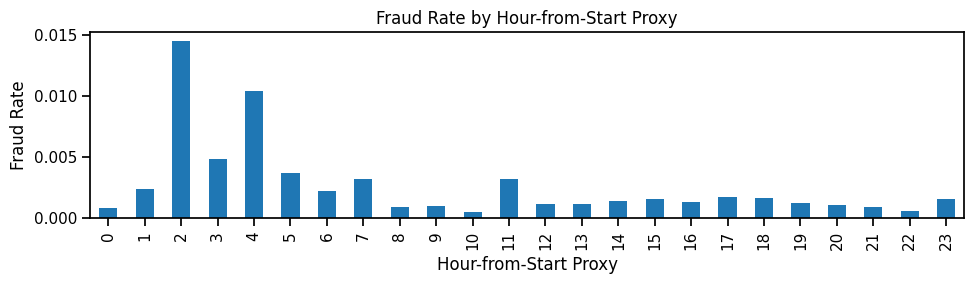

In [22]:
hour_rate = df.groupby("Hour_from_start_mod24")["Class"].mean().reindex(range(24)).fillna(0)
hour_rate.plot(kind="bar", figsize=(10,3), title="Fraud Rate by Hour-from-Start Proxy")
plt.xlabel("Hour-from-Start Proxy"); plt.ylabel("Fraud Rate")
plt.tight_layout(); plt.show()


## Fraud vs Normal Distribution by DayPart Proxy

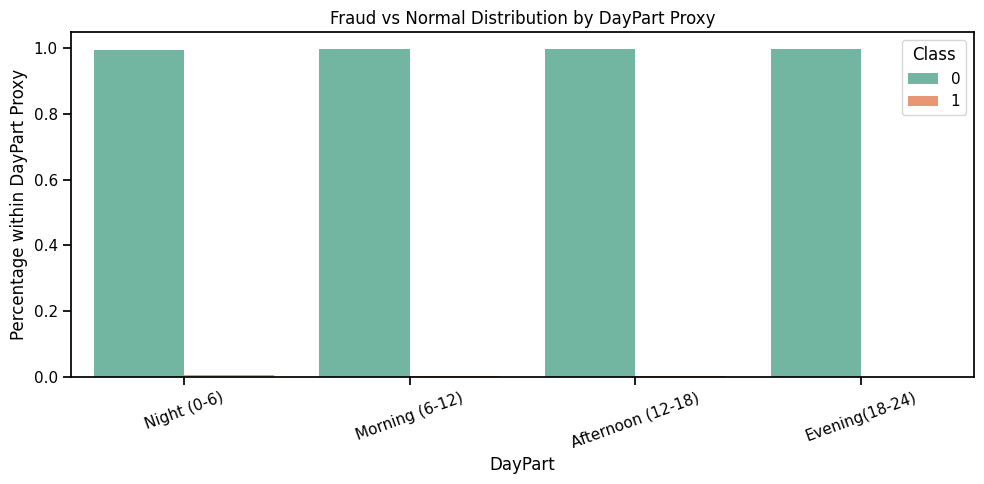

In [23]:
day_counts = df.groupby(["DayPart","Class"]).size().reset_index(name="Count")
day_total  = day_counts.groupby("DayPart")["Count"].transform("sum")
day_counts["Pct"] = day_counts["Count"] / day_total

sns.barplot(x="DayPart", y="Pct", hue="Class", data=day_counts, palette="Set2")
plt.title("Fraud vs Normal Distribution by DayPart Proxy")
plt.ylabel("Percentage within DayPart Proxy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Cumulative share of fraud by Amount rank


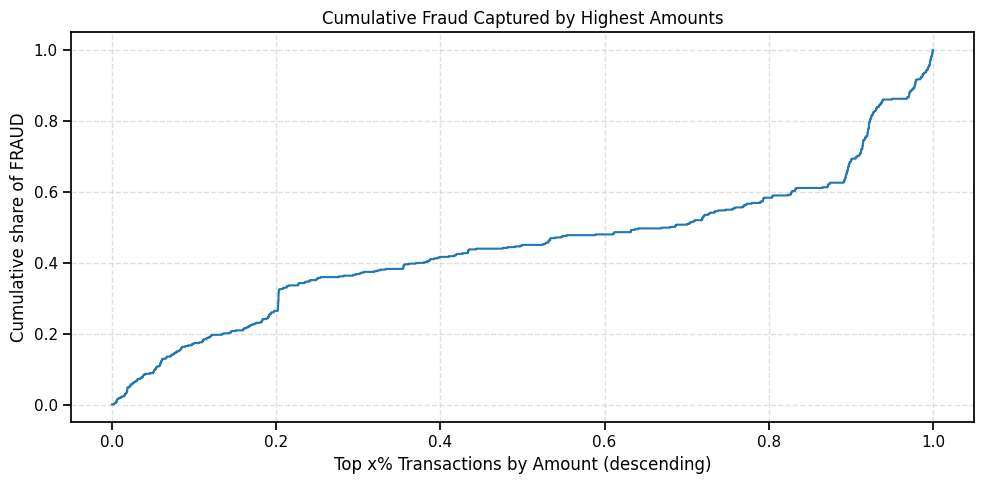

In [24]:
tmp = df[["Amount","Class"]].sort_values("Amount", ascending=False).reset_index(drop=True)
tmp["cum_tx"] = np.arange(1, len(tmp)+1) / len(tmp)
tmp["cum_fraud"] = tmp["Class"].cumsum() / tmp["Class"].sum()

plt.plot(tmp["cum_tx"], tmp["cum_fraud"])
plt.xlabel("Top x% Transactions by Amount (descending)")
plt.ylabel("Cumulative share of FRAUD")
plt.title("Cumulative Fraud Captured by Highest Amounts")
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Time-based Split (no look-ahead leakage)

In [25]:
df_sorted = df.sort_values("Time").reset_index(drop=True)
cut = int(0.8 * len(df_sorted))
train_df, test_df = df_sorted.iloc[:cut], df_sorted.iloc[cut:]

# Inner validation from train (time-ordered)
cut_in = int(0.8 * len(train_df))
train__df, val_df = train_df.iloc[:cut_in], train_df.iloc[cut_in:]

X_train , y_train = train__df[features], train__df[target].astype(int)
X_val   , y_val   = val_df[features]  , val_df[target].astype(int)
X_test  , y_test  = test_df[features] , test_df[target].astype(int)

print("Inner-Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
print("Train prevalence:", y_train.mean(), "| Test prevalence:", y_test.mean())


Inner-Train: 181584 | Val: 45396 | Test: 56746
Train prevalence: 0.001910961318177813 | Test prevalence: 0.0013040566735981391


### Split Quality Check

Because fraud prevalence can shift over time, the train, validation, and test windows should be inspected separately before interpreting model metrics.

In [26]:
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(y_train), len(y_val), len(y_test)],
    "Frauds": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "Fraud Rate (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100,
    ],
})

display(split_summary.round(4))

,Split,Rows,Frauds,Fraud Rate (%)
0,Train,181584,347,0.1911
1,Validation,45396,52,0.1145
2,Test,56746,74,0.1304


# Utilities: Metrics, Thresholds, Cost

In [27]:
def evaluate_block(y_true, y_score, thr=0.5):
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return dict(
        threshold=float(thr),
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred),
        f1=f1_score(y_true, y_pred, zero_division=0),
        roc_auc=roc_auc_score(y_true, y_score),
        auprc=average_precision_score(y_true, y_score),
        brier=brier_score_loss(y_true, y_score),
        tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn)
    )

def thr_for_precision(y_true, y_score, target_p=0.90):
    ps, rs, ths = precision_recall_curve(y_true, y_score)
    hits = np.where(ps[:-1] >= target_p)[0]
    if hits.size:
        i = hits[0]
        return float(ths[i]), float(ps[i]), float(rs[i])
    i = np.argmax(0.5*ps[:-1] + 0.5*rs[:-1])
    return float(ths[i]), float(ps[i]), float(rs[i])


def thr_min_cost(y_true , y_score , cost_fp=COST_FP , cost_fn=COST_FN, grid=1001):
    best_thr , best_cost = 0.5, float("inf")
    for t in np.linspace(0,1, grid):
        yhat = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true ,yhat, labels=[0,1]).ravel()
        cost = fp*cost_fp + fn*cost_fn
        if cost < best_cost:
            best_thr , best_cost = float(t), float(cost)
    return best_thr , best_cost

def realized_cost(y_true, y_score, thr, cost_fp=COST_FP, cost_fn=COST_FN):
    yhat = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0,1]).ravel()
    return fp*cost_fp + fn*cost_fn

def plot_pr_roc(y_true, y_score ,title):
    ps,rs , _ = precision_recall_curve(y_true , y_score)
    plt.plot(rs, ps)
    plt.axhline(y_true.mean(), ls="--", alpha=0.5)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{title} — PR (AP={average_precision_score(y_true,y_score):.3f})")
    plt.grid(True, ls="--", alpha=0.4); plt.tight_layout(); plt.show()
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.plot(fpr, tpr)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"{title} — ROC (AUC={roc_auc_score(y_true,y_score):.3f})")
    plt.grid(True, ls="--", alpha=0.4); plt.tight_layout(); plt.show()

def reliability_plot(y_true, y_score, title, bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=bins, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0,1],[0,1], "--", alpha=0.6)
    plt.xlabel("Predicted probability"); plt.ylabel("Empirical probability")
    plt.title(title + f" — Brier={brier_score_loss(y_true, y_score):.4f}")
    plt.grid(True, ls="--", alpha=0.4); plt.tight_layout(); plt.show()

def expected_calibration_error(y_true, y_prob, n_bins=15):
    """
    Simple (non-standardized) ECE: weighted avg |acc - conf| over quantized bins.
    For formal comparisons, prefer standardized definitions.
    """
    bins = np.linspace(0.0, 1.0, n_bins+1)
    idx = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = (idx == b)
        if not np.any(mask):
            continue
        conf = y_prob[mask].mean()
        acc  = y_true[mask].mean()
        ece += (mask.mean()) * abs(acc - conf)
    return float(ece)

rng = np.random.default_rng(SEED)
def bootstrap_ci(metric_fn, y_true, y_score, B=300, alpha=0.05):
    n = len(y_true)
    vals = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        vals.append(metric_fn(y_true[idx], y_score[idx]))
    lo = np.quantile(vals, alpha/2)
    hi = np.quantile(vals, 1 - alpha/2)
    return float(lo), float(hi)


def sweep_thresholds(y_true, y_prob, costs=(COST_FP, COST_FN)):
    ths = np.linspace(0, 1, 101)
    rows = []
    for t in ths:
        yhat = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0,1]).ravel()
        prec = precision_score(y_true, yhat, zero_division=0)
        rec  = recall_score(y_true, yhat)
        f1   = f1_score(y_true, yhat, zero_division=0)
        cost = fp*costs[0] + fn*costs[1]
        rows.append([t, prec, rec, f1, tp, fp, fn, tn, cost])
    return pd.DataFrame(rows, columns=["thr","precision","recall","f1","tp","fp","fn","tn","cost"])

def plot_alerts_and_savings(df_sweep, title):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    # Alerts = predicted positives = tp+fp
    ax[0].plot(df_sweep["thr"], df_sweep["tp"]+df_sweep["fp"])
    ax[0].set_title(title+" — Alerts vs Threshold"); ax[0].set_xlabel("Threshold"); ax[0].set_ylabel("#Alerts")
    # Savings = (tp * FN_cost) - (fp * FP_cost)
    savings = df_sweep["tp"]*COST_FN - df_sweep["fp"]*COST_FP
    ax[1].plot(df_sweep["thr"], savings)
    ax[1].set_title(title+" — Net Savings vs Threshold"); ax[1].set_xlabel("Threshold"); ax[1].set_ylabel("Net Savings ($)")
    plt.tight_layout(); plt.show()


## Baseline Logistic + RF

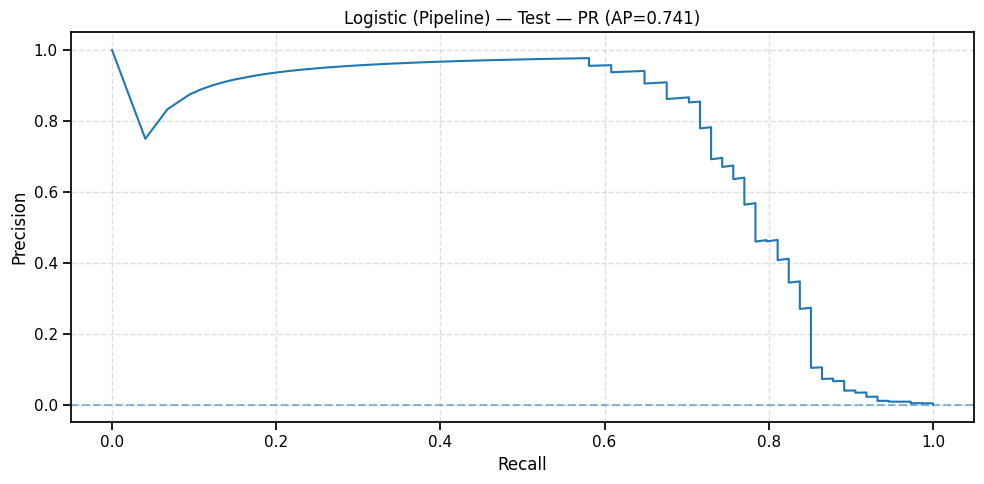

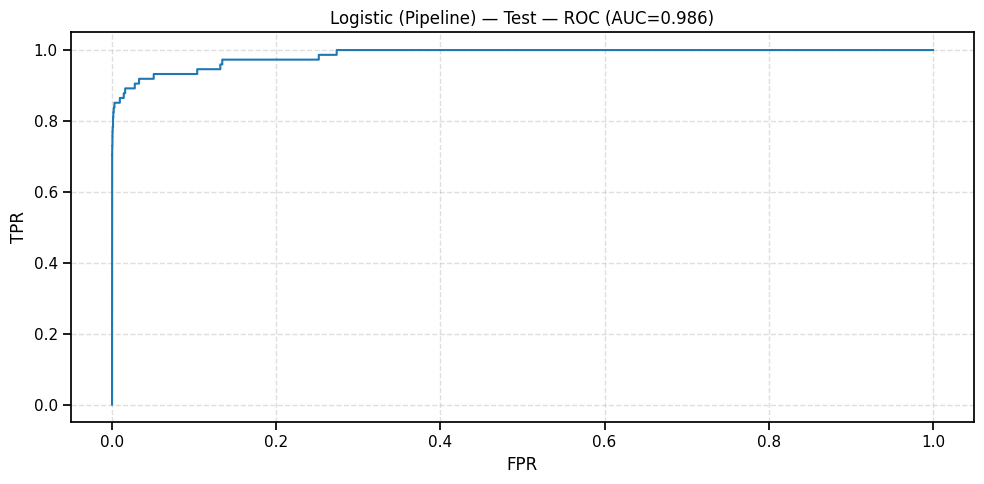

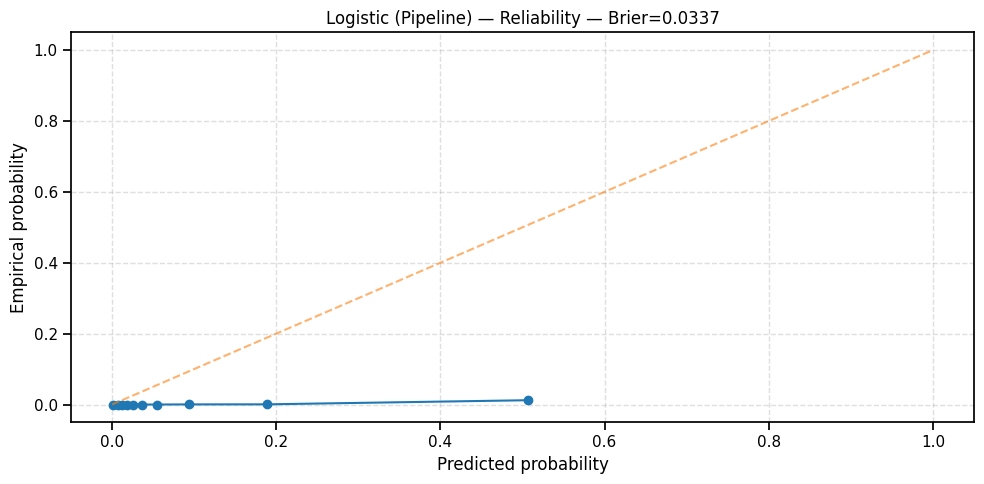

[Logistic|Pipeline] VAL AUPRC: 0.7749693650102897
[Logistic|Pipeline] TEST AUPRC: 0.7414676125025982


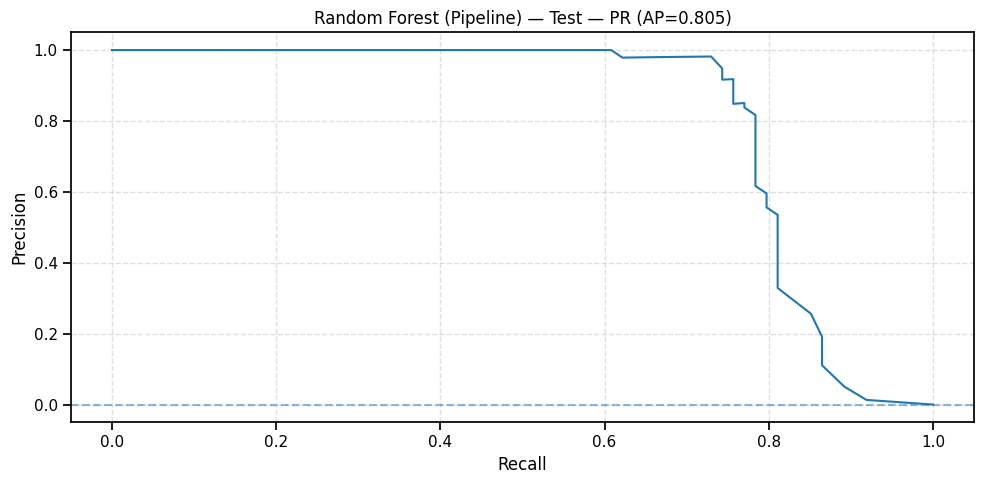

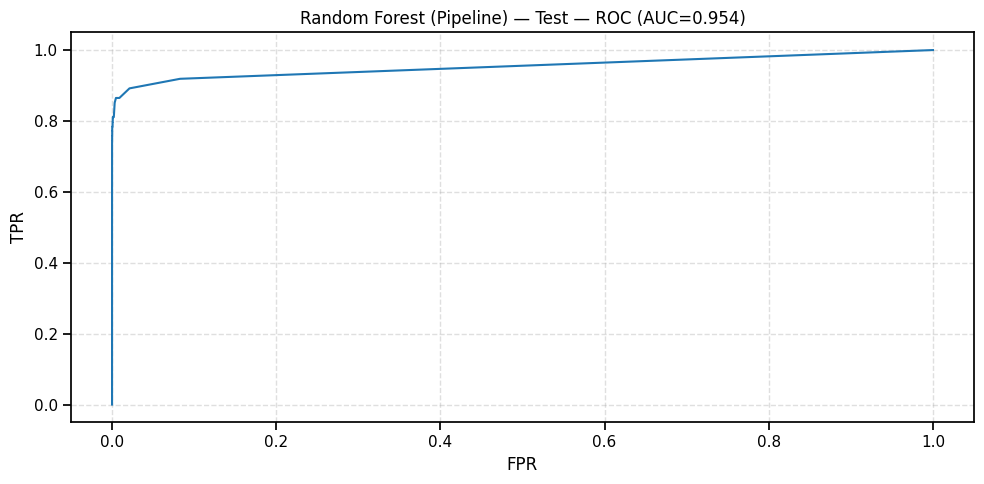

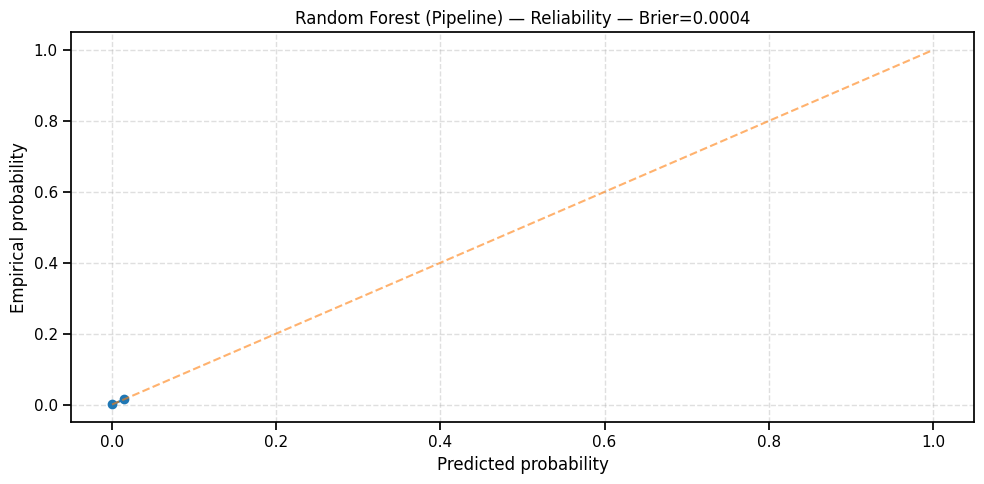

[RF|Pipeline] VAL AUPRC: 0.7686420745950832
[RF|Pipeline] TEST AUPRC: 0.8053069823934353


In [28]:
# Logistic Regression
logit_pipe = ImbPipeline(steps=[
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))
])
logit_pipe.fit(X_train, y_train)

val_log_proba  = logit_pipe.predict_proba(X_val)[:, 1]
test_log_proba = logit_pipe.predict_proba(X_test)[:, 1]


plot_pr_roc(y_test, test_log_proba, "Logistic (Pipeline) — Test")
reliability_plot(y_test, test_log_proba, "Logistic (Pipeline) — Reliability")
print("[Logistic|Pipeline] VAL AUPRC:",  average_precision_score(y_val , val_log_proba))
print("[Logistic|Pipeline] TEST AUPRC:", average_precision_score(y_test, test_log_proba))

# Random Forest
rf_pipe = ImbPipeline(steps=[
    ("clf", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)

val_rf_proba  = rf_pipe.predict_proba(X_val)[:, 1]
test_rf_proba = rf_pipe.predict_proba(X_test)[:, 1]


plot_pr_roc(y_test, test_rf_proba, "Random Forest (Pipeline) — Test")
reliability_plot(y_test, test_rf_proba, "Random Forest (Pipeline) — Reliability")
print("[RF|Pipeline] VAL AUPRC:",  average_precision_score(y_val , val_rf_proba))
print("[RF|Pipeline] TEST AUPRC:", average_precision_score(y_test, test_rf_proba))


##  Strong Model — XGBoost 

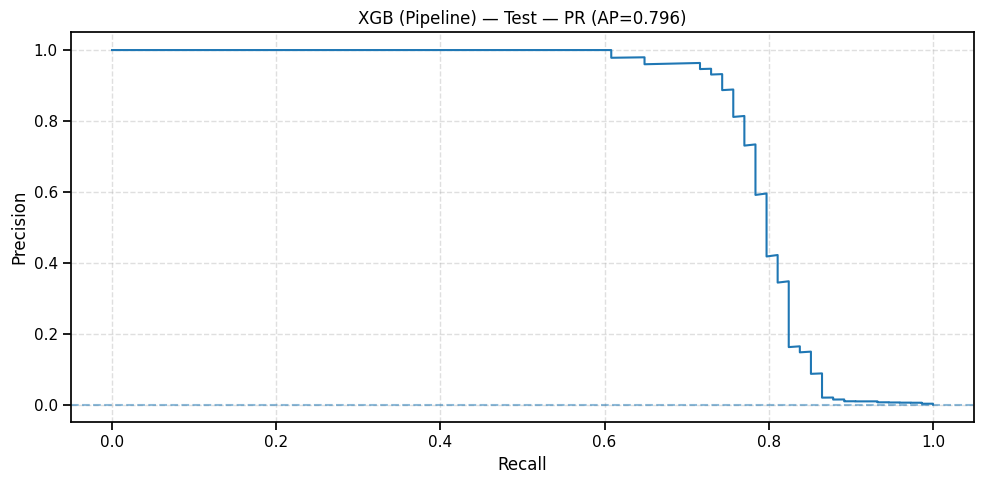

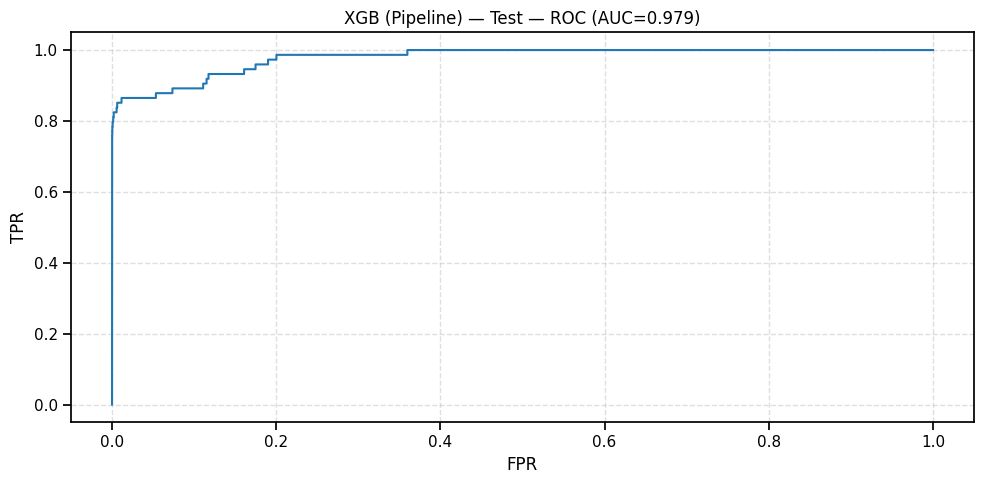

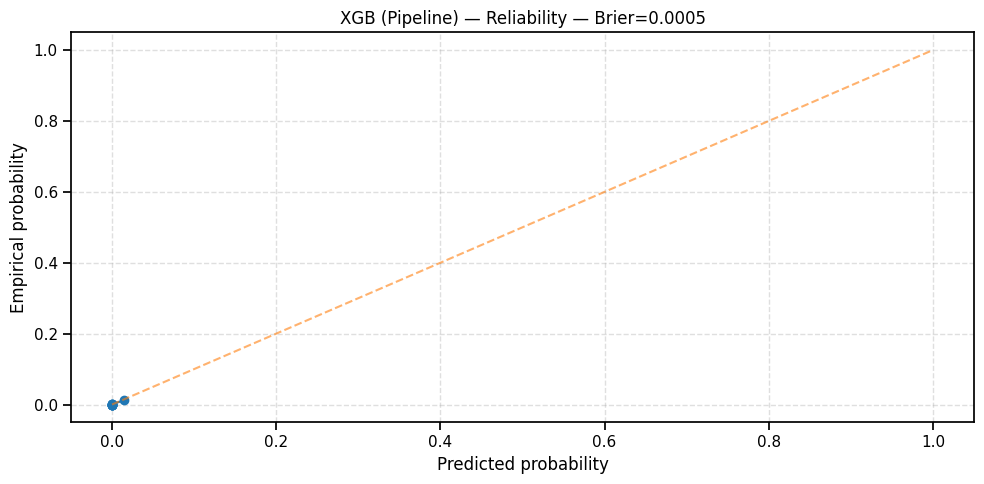

[XGB|Pipeline] VAL AUPRC: 0.779139455023324
[XGB|Pipeline] TEST AUPRC: 0.7964386659638674


In [29]:
pos, neg = int((y_train==1).sum()), int((y_train==0).sum())
spw = neg / max(1, pos)  # scale_pos_weight ≈ imbalance ratio

xgb_pipe = ImbPipeline(steps=[
    ("model", XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        tree_method="hist", random_state=SEED,
        scale_pos_weight=spw, n_jobs=-1, eval_metric="aucpr"
    ))
])
xgb_pipe.fit(X_train, y_train)

val_xgb_proba  = xgb_pipe.predict_proba(X_val)[:, 1]
test_xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]

plot_pr_roc(y_test, test_xgb_proba, "XGB (Pipeline) — Test")
reliability_plot(y_test, test_xgb_proba, "XGB (Pipeline) — Reliability")
print("[XGB|Pipeline] VAL AUPRC:",  average_precision_score(y_val, val_xgb_proba))
print("[XGB|Pipeline] TEST AUPRC:", average_precision_score(y_test, test_xgb_proba))


# Calibration (Isotonic) with TimeSeriesSplit on TRAIN

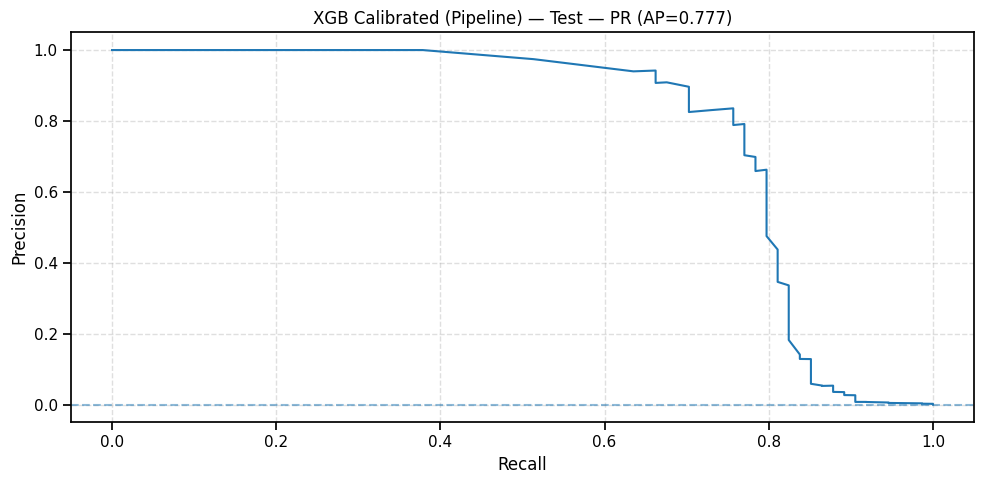

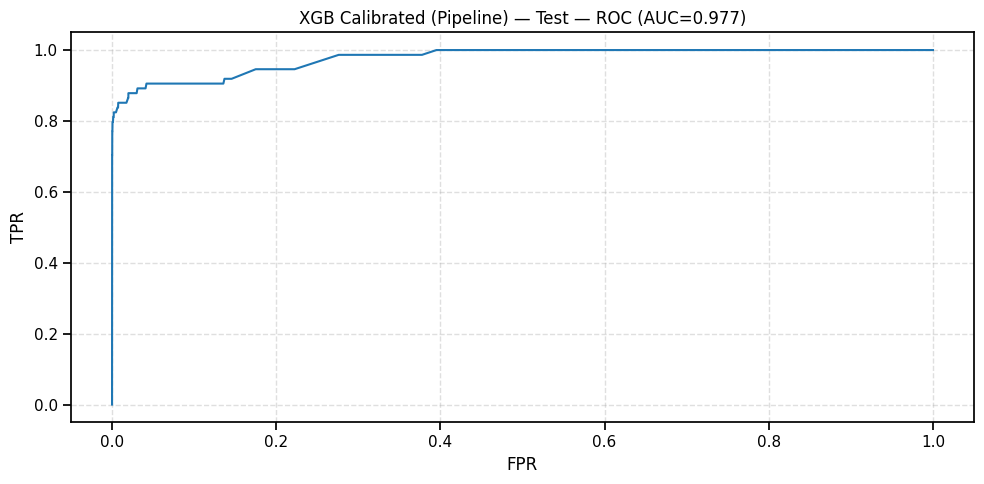

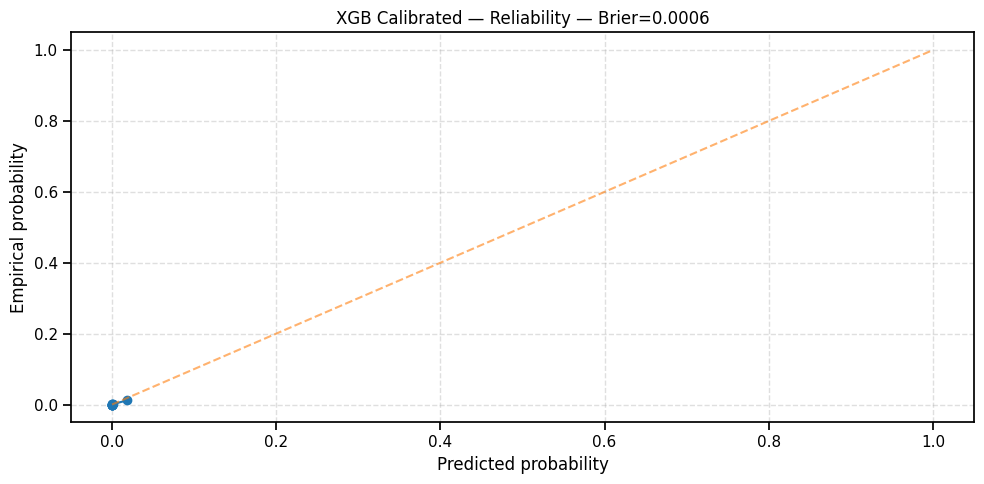

[XGB-Cal|Pipeline] VAL AUPRC: 0.7584741949513761
[XGB-Cal|Pipeline] TEST AUPRC: 0.7774704438428369
ECE[Test] XGB-Cal: 0.000775171498854702


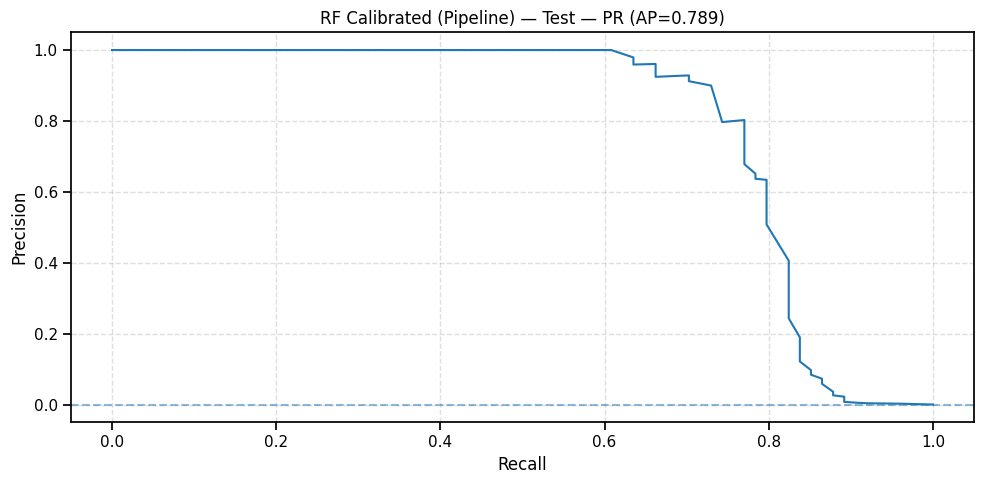

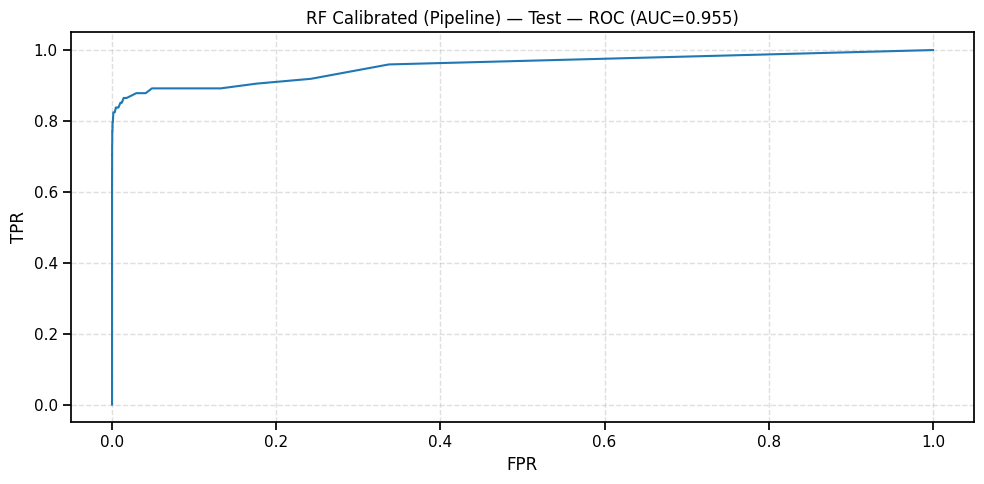

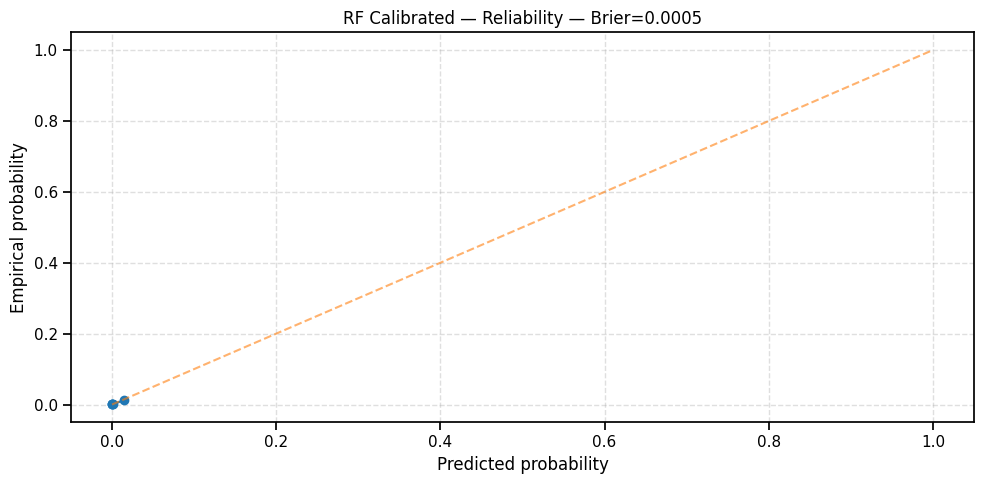

[RF-Cal] VAL AUPRC: 0.7500814806131584
[RF-Cal] TEST AUPRC: 0.7893729914516632
ECE[Test] RF-Cal : 0.00032490561177746463


In [30]:
cal_cv = TimeSeriesSplit(n_splits=3)

# Calibrated XGB
xgb_cal = CalibratedClassifierCV(estimator=xgb_pipe, method="isotonic", cv=cal_cv)
xgb_cal.fit(X_train, y_train)
val_xgb_cal  = xgb_cal.predict_proba(X_val)[:, 1]
test_xgb_cal = xgb_cal.predict_proba(X_test)[:, 1]

plot_pr_roc(y_test, test_xgb_cal, "XGB Calibrated (Pipeline) — Test")
reliability_plot(y_test, test_xgb_cal, "XGB Calibrated — Reliability")
print("[XGB-Cal|Pipeline] VAL AUPRC:",  average_precision_score(y_val, val_xgb_cal))
print("[XGB-Cal|Pipeline] TEST AUPRC:", average_precision_score(y_test, test_xgb_cal))
print("ECE[Test] XGB-Cal:", expected_calibration_error(y_test.values, test_xgb_cal, n_bins=15))


# Calibrated RF
rf_cal = CalibratedClassifierCV(estimator=rf_pipe, method="isotonic", cv=cal_cv)
rf_cal.fit(X_train, y_train)
val_rf_cal  = rf_cal.predict_proba(X_val)[:, 1]
test_rf_cal = rf_cal.predict_proba(X_test)[:, 1]

plot_pr_roc(y_test, test_rf_cal, "RF Calibrated (Pipeline) — Test")
reliability_plot(y_test, test_rf_cal, "RF Calibrated — Reliability")
print("[RF-Cal] VAL AUPRC:",  average_precision_score(y_val,  val_rf_cal))
print("[RF-Cal] TEST AUPRC:", average_precision_score(y_test, test_rf_cal))
print("ECE[Test] RF-Cal :", expected_calibration_error(y_test.values, test_rf_cal,  n_bins=15))




# Overlay PR Curves

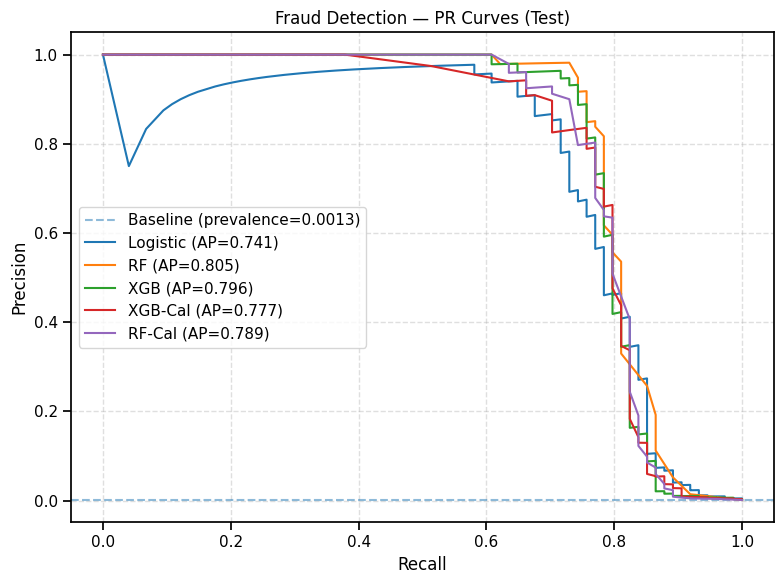

In [31]:

def plot_pr_overlay(y_true, preds_dict, title="PR Curves — Overlay"):
    plt.figure(figsize=(8,6))
    base = y_true.mean()
    plt.axhline(base, ls="--", alpha=0.5, label=f"Baseline (prevalence={base:.4f})")

    for name, y_prob in preds_dict.items():
        ps, rs, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        plt.plot(rs, ps, label=f"{name} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

preds_test = {
    "Logistic":        test_log_proba,
    "RF":              test_rf_proba,
    "XGB":             test_xgb_proba,
    "XGB-Cal":         test_xgb_cal,
        "RF-Cal":          test_rf_cal,
}
plot_pr_overlay(y_test, preds_test, title="Fraud Detection — PR Curves (Test)")


# Reliability Overlay for key models

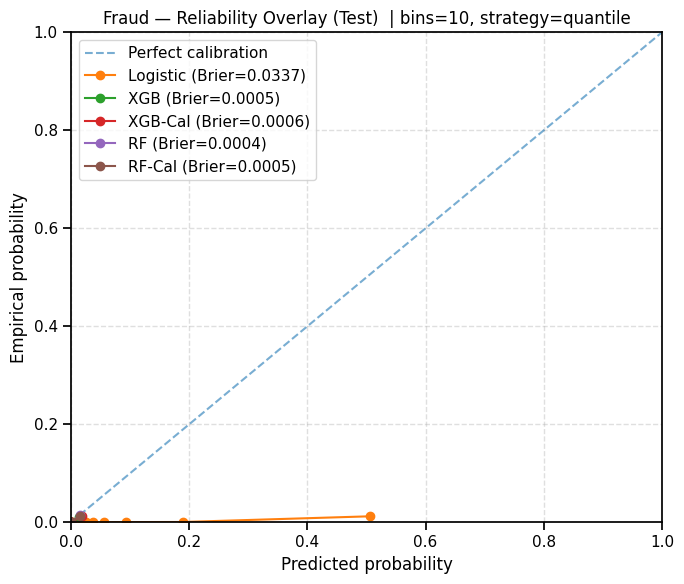

In [32]:
def reliability_overlay(y_true, preds_dict, bins=10, strategy="quantile",
                        title="Reliability (Calibration) — Overlay"):
    plt.figure(figsize=(7,6))
    plt.plot([0,1],[0,1], "--", alpha=0.6, label="Perfect calibration")

    for name, y_prob in preds_dict.items():
        prob_true, prob_pred = calibration_curve(y_true, y_prob,
                                                n_bins=bins, strategy=strategy)
        brier = brier_score_loss(y_true, y_prob)
        plt.plot(prob_pred, prob_true, marker="o", label=f"{name} (Brier={brier:.4f})")

    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel("Predicted probability")
    plt.ylabel("Empirical probability")
    plt.title(title + f"  | bins={bins}, strategy={strategy}")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

reliab_models = {
    "Logistic": test_log_proba,
    "XGB":      test_xgb_proba,
    "XGB-Cal":  test_xgb_cal,
    "RF":       test_rf_proba,
    "RF-Cal":   test_rf_cal,
}
reliability_overlay(y_test, reliab_models, bins=10, strategy="quantile",
                    title="Fraud — Reliability Overlay (Test)")


# Threshold Tuning XGB-Cal

[VAL|XGB-Cal] Thr@P≥90%: thr=0.772, P=0.900, R=0.692
[VAL|XGB-Cal] Thr@Min-Cost: thr=0.169, Cost=2360.00

===== XGB-Cal — TEST EVAL =====
XGB-Cal@Test (Thr@P≥90%): {'threshold': 0.7718102931976318, 'precision': 0.9245283018867925, 'recall': 0.6621621621621622, 'f1': 0.7716535433070866, 'roc_auc': 0.9767545725426161, 'auprc': 0.7774704438428369, 'brier': 0.0005960251066110958, 'tp': 49, 'fp': 4, 'fn': 25, 'tn': 56668}
XGB-Cal@Test (Thr@Min-Cost): {'threshold': 0.169, 'precision': 0.43478260869565216, 'recall': 0.8108108108108109, 'f1': 0.5660377358490566, 'roc_auc': 0.9767545725426161, 'auprc': 0.7774704438428369, 'brier': 0.0005960251066110958, 'tp': 60, 'fp': 78, 'fn': 14, 'tn': 56594}
[TEST|XGB-Cal] Realized Cost @ P≥90% thr (0.772): 5020.00
[TEST|XGB-Cal] Realized Cost @ Min-Cost thr (0.169): 3190.00


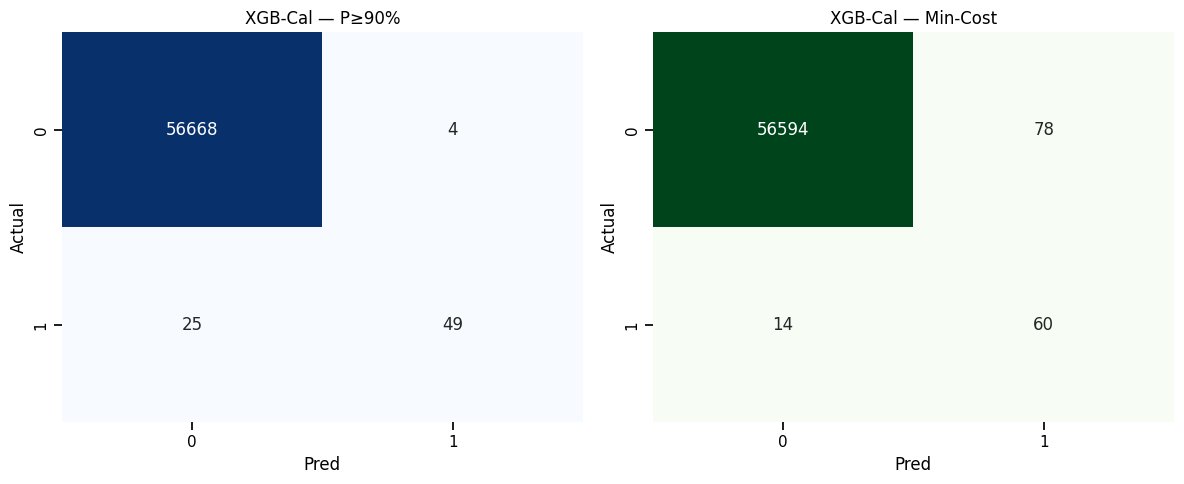

In [33]:
thr_p90_xgb, p_val_xgb, r_val_xgb = thr_for_precision(y_val, val_xgb_cal, target_p=0.90)
thr_cost_xgb, best_cost_val_xgb = thr_min_cost(y_val,  val_xgb_cal, cost_fp=COST_FP, cost_fn=COST_FN)

print(f"[VAL|XGB-Cal] Thr@P≥90%: thr={thr_p90_xgb:.3f}, P={p_val_xgb:.3f}, R={r_val_xgb:.3f}")
print(f"[VAL|XGB-Cal] Thr@Min-Cost: thr={thr_cost_xgb:.3f}, Cost={best_cost_val_xgb:.2f}")

eval_xgb_p90  = evaluate_block(y_test, test_xgb_cal, thr_p90_xgb)
eval_xgb_cost = evaluate_block(y_test, test_xgb_cal, thr_cost_xgb)
cm_xgb_p90  = confusion_matrix(y_test, (test_xgb_cal >= thr_p90_xgb ).astype(int))
cm_xgb_cost = confusion_matrix(y_test, (test_xgb_cal >= thr_cost_xgb).astype(int))

print("\n===== XGB-Cal — TEST EVAL =====")
print("XGB-Cal@Test (Thr@P≥90%):",  eval_xgb_p90)
print("XGB-Cal@Test (Thr@Min-Cost):", eval_xgb_cost)

cost_xgb_p90 = realized_cost(y_test, test_xgb_cal, thr_p90_xgb,  cost_fp=COST_FP, cost_fn=COST_FN)
cost_xgb_min = realized_cost(y_test, test_xgb_cal, thr_cost_xgb, cost_fp=COST_FP, cost_fn=COST_FN)
print(f"[TEST|XGB-Cal] Realized Cost @ P≥90% thr ({thr_p90_xgb:.3f}): {cost_xgb_p90:.2f}")
print(f"[TEST|XGB-Cal] Realized Cost @ Min-Cost thr ({thr_cost_xgb:.3f}): {cost_xgb_min:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(cm_xgb_p90,  annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('XGB-Cal — P≥90%');  axes[0].set_xlabel('Pred'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_xgb_cost, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('XGB-Cal — Min-Cost'); axes[1].set_xlabel('Pred'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()


# Threshold tuning RF-Cal



[VAL|RF-Cal] Thr@P≥90%: thr=0.636, P=0.905, R=0.731
[VAL|RF-Cal] Thr@Min-Cost: thr=0.065, Cost=2215.00

===== RF-Cal — TEST EVAL =====
RF-Cal@Test (Thr@P≥90%): {'threshold': 0.6355820105820106, 'precision': 0.9, 'recall': 0.7297297297297297, 'f1': 0.8059701492537313, 'roc_auc': 0.9548839362018711, 'auprc': 0.7893729914516632, 'brier': 0.00046776380827147454, 'tp': 54, 'fp': 6, 'fn': 20, 'tn': 56666}
RF-Cal@Test (Thr@Min-Cost): {'threshold': 0.065, 'precision': 0.5728155339805825, 'recall': 0.7972972972972973, 'f1': 0.6666666666666666, 'roc_auc': 0.9548839362018711, 'auprc': 0.7893729914516632, 'brier': 0.00046776380827147454, 'tp': 59, 'fp': 44, 'fn': 15, 'tn': 56628}
[TEST|RF-Cal] Realized Cost @ P≥90% thr (0.636): 4030.00
[TEST|RF-Cal] Realized Cost @ Min-Cost thr (0.065): 3220.00


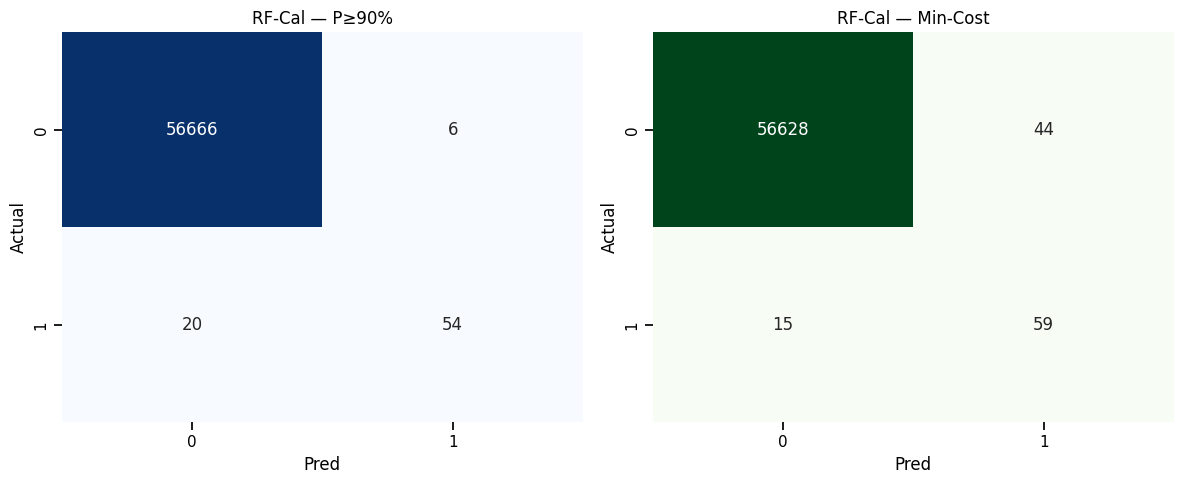

In [34]:
thr_p90_rf, p_val_rf, r_val_rf = thr_for_precision(y_val, val_rf_cal, target_p=0.90)
thr_cost_rf, best_cost_val_rf = thr_min_cost(y_val,  val_rf_cal, cost_fp=COST_FP, cost_fn=COST_FN)

print(f"\n[VAL|RF-Cal] Thr@P≥90%: thr={thr_p90_rf:.3f}, P={p_val_rf:.3f}, R={r_val_rf:.3f}")
print(f"[VAL|RF-Cal] Thr@Min-Cost: thr={thr_cost_rf:.3f}, Cost={best_cost_val_rf:.2f}")

eval_rf_p90  = evaluate_block(y_test, test_rf_cal, thr_p90_rf)
eval_rf_cost = evaluate_block(y_test, test_rf_cal, thr_cost_rf)
cm_rf_p90  = confusion_matrix(y_test, (test_rf_cal >= thr_p90_rf ).astype(int))
cm_rf_cost = confusion_matrix(y_test, (test_rf_cal >= thr_cost_rf).astype(int))

print("\n===== RF-Cal — TEST EVAL =====")
print("RF-Cal@Test (Thr@P≥90%):",  eval_rf_p90)
print("RF-Cal@Test (Thr@Min-Cost):", eval_rf_cost)

cost_rf_p90 = realized_cost(y_test, test_rf_cal, thr_p90_rf,  cost_fp=COST_FP, cost_fn=COST_FN)
cost_rf_min = realized_cost(y_test, test_rf_cal, thr_cost_rf, cost_fp=COST_FP, cost_fn=COST_FN)
print(f"[TEST|RF-Cal] Realized Cost @ P≥90% thr ({thr_p90_rf:.3f}): {cost_rf_p90:.2f}")
print(f"[TEST|RF-Cal] Realized Cost @ Min-Cost thr ({thr_cost_rf:.3f}): {cost_rf_min:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(cm_rf_p90,  annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('RF-Cal — P≥90%');  axes[0].set_xlabel('Pred'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_rf_cost, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('RF-Cal — Min-Cost'); axes[1].set_xlabel('Pred'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()


#  Cost & Alerts vs Threshold

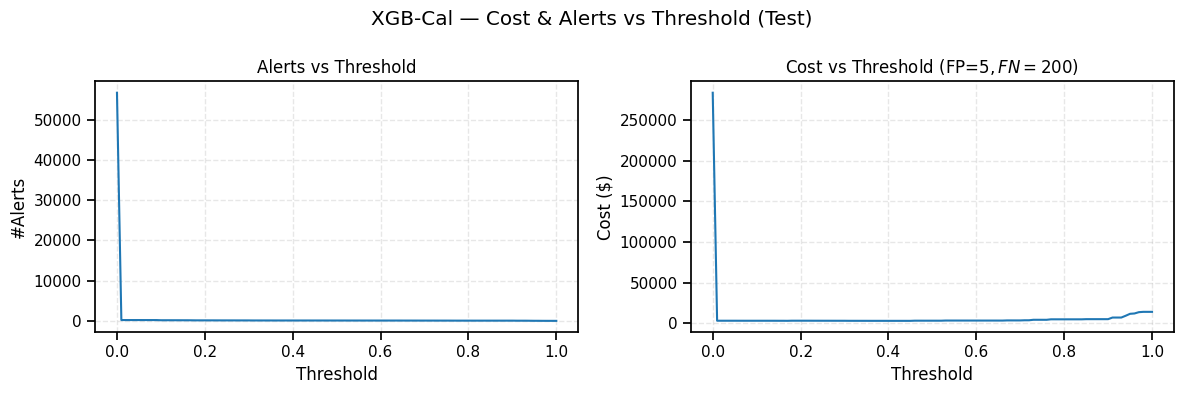

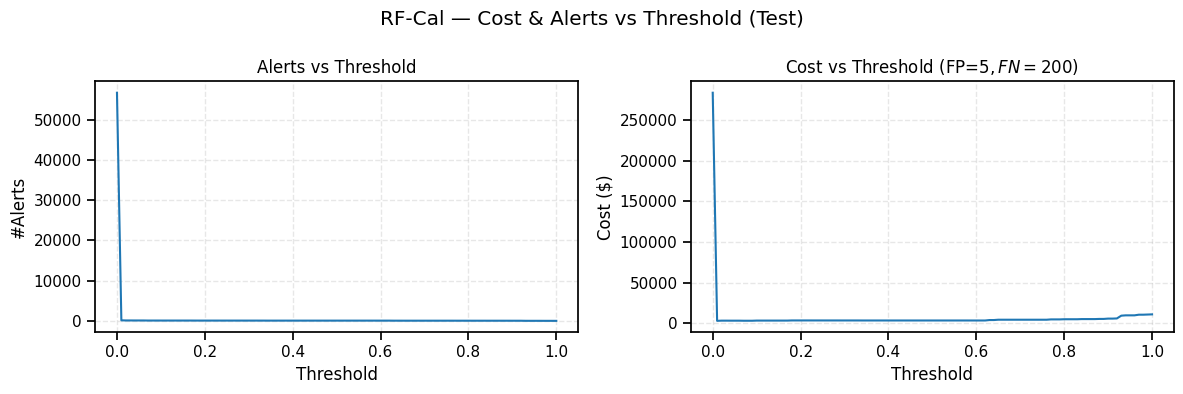

In [35]:
def plot_cost_and_alerts(y_true, y_prob, cost_fp=5.0, cost_fn=200.0, title="Cost & Alerts vs Threshold"):
    df_sweep = sweep_thresholds(y_true, y_prob, costs=(cost_fp, cost_fn))
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    # Alerts = tp + fp
    ax[0].plot(df_sweep["thr"], df_sweep["tp"] + df_sweep["fp"])
    ax[0].set_title("Alerts vs Threshold")
    ax[0].set_xlabel("Threshold"); ax[0].set_ylabel("#Alerts")
    ax[0].grid(True, ls="--", alpha=0.3)

    # Cost curve
    ax[1].plot(df_sweep["thr"], df_sweep["cost"])
    ax[1].set_title(f"Cost vs Threshold (FP=${cost_fp:.0f}, FN=${cost_fn:.0f})")
    ax[1].set_xlabel("Threshold"); ax[1].set_ylabel("Cost ($)")
    ax[1].grid(True, ls="--", alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    return df_sweep

df_xgbcal_sweep = plot_cost_and_alerts(y_test, test_xgb_cal, cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="XGB-Cal — Cost & Alerts vs Threshold (Test)")
df_rfcal_sweep  = plot_cost_and_alerts(y_test, test_rf_cal,  cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="RF-Cal — Cost & Alerts vs Threshold (Test)")


## Calibrated Models — Side-by-Side

In [36]:
def summarise_model(name, y_true, y_prob, thr_p90, thr_cost):
    ap = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    ece = expected_calibration_error(y_true.values, y_prob, n_bins=15)
    cost_p90 = realized_cost(y_true, y_prob, thr_p90, COST_FP, COST_FN)
    cost_min = realized_cost(y_true, y_prob, thr_cost, COST_FP, COST_FN)
    ap_lo, ap_hi = bootstrap_ci(average_precision_score, y_true.values, y_prob)
    return {
        "Model": name, "AP(Test)": ap, "AP 95% CI": f"[{ap_lo:.3f}, {ap_hi:.3f}]",
        "ROC-AUC(Test)": roc, "Brier(Test)": brier, "ECE(15)": ece,
        "Thr@P90(val)": float(thr_p90), "Thr@MinCost(val)": float(thr_cost),
        "Cost@Test@P90": cost_p90, "Cost@Test@MinCost": cost_min,
    }

summary_df = pd.DataFrame([
    summarise_model("RF-Cal",  y_test, test_rf_cal,  thr_p90_rf,  thr_cost_rf),
    summarise_model("XGB-Cal", y_test, test_xgb_cal, thr_p90_xgb, thr_cost_xgb),
]).sort_values("AP(Test)", ascending=False)

display(summary_df.round(4))


,Model,AP(Test),AP 95% CI,ROC-AUC(Test),Brier(Test),ECE(15),Thr@P90(val),Thr@MinCost(val),Cost@Test@P90,Cost@Test@MinCost
0,RF-Cal,0.7894,"[0.700, 0.867]",0.9549,0.0005,0.0003,0.6356,0.065,4030.0,3220.0
1,XGB-Cal,0.7775,"[0.695, 0.868]",0.9768,0.0006,0.0008,0.7718,0.169,5020.0,3190.0


### Raw vs Calibrated Probability Scores

This table compares raw and calibrated model scores.

AUPRC measures ranking quality, where higher is better.  
Brier Score and ECE measure probability calibration quality, where lower is better.

Calibration can improve probability reliability even when AUPRC becomes slightly lower. That is why calibrated models are useful for threshold-based fraud operations.

In [37]:
y_test_array = np.asarray(y_test)

calibration_comparison = pd.DataFrame([
    {
        "Model": "RF",
        "Variant": "Raw",
        "Test AUPRC": average_precision_score(y_test_array, test_rf_proba),
        "Brier Score": brier_score_loss(y_test_array, test_rf_proba),
        "ECE": expected_calibration_error(y_test_array, test_rf_proba, n_bins=15),
    },
    {
        "Model": "RF",
        "Variant": "Calibrated",
        "Test AUPRC": average_precision_score(y_test_array, test_rf_cal),
        "Brier Score": brier_score_loss(y_test_array, test_rf_cal),
        "ECE": expected_calibration_error(y_test_array, test_rf_cal, n_bins=15),
    },
    {
        "Model": "XGB",
        "Variant": "Raw",
        "Test AUPRC": average_precision_score(y_test_array, test_xgb_proba),
        "Brier Score": brier_score_loss(y_test_array, test_xgb_proba),
        "ECE": expected_calibration_error(y_test_array, test_xgb_proba, n_bins=15),
    },
    {
        "Model": "XGB",
        "Variant": "Calibrated",
        "Test AUPRC": average_precision_score(y_test_array, test_xgb_cal),
        "Brier Score": brier_score_loss(y_test_array, test_xgb_cal),
        "ECE": expected_calibration_error(y_test_array, test_xgb_cal, n_bins=15),
    },
])

display(calibration_comparison.round(6))

,Model,Variant,Test AUPRC,Brier Score,ECE
0,RF,Raw,0.805307,0.000427,0.000388
1,RF,Calibrated,0.789373,0.000468,0.000325
2,XGB,Raw,0.796439,0.000451,0.000310
3,XGB,Calibrated,0.777470,0.000596,0.000775


# Alerts and Fraud caught per 100k

In [38]:
def summarize_ops(y_true, y_prob, thr, name, cost_fp=COST_FP, cost_fn=COST_FN):
    yhat = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0,1]).ravel()
    N = len(y_true)
    alerts = tp + fp
    cost = fp*cost_fp + fn*cost_fn
    savings = tp*cost_fn - fp*cost_fp

    return {
        "Model": name,
        "Threshold": float(thr),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Precision": precision_score(y_true, yhat, zero_division=0),
        "Recall": recall_score(y_true, yhat),
        "F1": f1_score(y_true, yhat, zero_division=0),
        "Alerts": int(alerts),
        "Alerts/100k":  (alerts / N) * 100000,
        "FraudCaught/100k": (tp / N) * 100000,
        "Cost($)": cost,
        "Cost/100k($)": (cost / N) * 100000,
        "NetSavings($)": savings
    }

ops_rows = []
ops_rows.append(summarize_ops(y_test, test_rf_cal,  thr_p90_rf,  "RF-Cal @P90"))
ops_rows.append(summarize_ops(y_test, test_rf_cal,  thr_cost_rf, "RF-Cal @MinCost"))
ops_rows.append(summarize_ops(y_test, test_xgb_cal, thr_p90_xgb, "XGB-Cal @P90"))
ops_rows.append(summarize_ops(y_test, test_xgb_cal, thr_cost_xgb,"XGB-Cal @MinCost"))
ops_df = pd.DataFrame(ops_rows)

prevalence = y_test.mean()
ops_df["Alerts%"] = (ops_df["Alerts/100k"] / 100000) * 100
ops_df["PrecisionLift(x)"] = ops_df["Precision"] / max(1e-9, prevalence)

cols_order = [
    "Model","Threshold",
    "TP","FP","FN","TN",
    "Precision","Recall","F1",
    "Alerts","Alerts%","Alerts/100k","FraudCaught/100k",
    "Cost($)","Cost/100k($)","NetSavings($)","PrecisionLift(x)"
]
ops_df = ops_df[cols_order].round(4)
display(ops_df)

cx_cost_rf  = realized_cost(y_test, test_rf_cal,  thr_p90_rf,  COST_FP, COST_FN)
cx_cost_xgb = realized_cost(y_test, test_xgb_cal, thr_p90_xgb, COST_FP, COST_FN)
cx_brier_rf, cx_brier_xgb = brier_score_loss(y_test, test_rf_cal), brier_score_loss(y_test, test_xgb_cal)

cx_best_by_cost  = "RF-Cal"  if cx_cost_rf  <= cx_cost_xgb  else "XGB-Cal"
cx_best_by_brier = "RF-Cal"  if cx_brier_rf <= cx_brier_xgb else "XGB-Cal"

print(f"[CX-first @P90] Lower Cost: {cx_best_by_cost}  | Better Brier: {cx_best_by_brier}")

min_cost_rf  = realized_cost(y_test, test_rf_cal,  thr_cost_rf,  COST_FP, COST_FN)
min_cost_xgb = realized_cost(y_test, test_xgb_cal, thr_cost_xgb, COST_FP, COST_FN)
best_cost_model = "RF-Cal" if min_cost_rf <= min_cost_xgb else "XGB-Cal"
print(f"[Cost-first @MinCost] Lower Cost: {best_cost_model}")

print(f"Prevalence(Test) = {prevalence:.4%} | Baseline Precision = {prevalence:.4%}")


,Model,Threshold,TP,FP,FN,TN,Precision,Recall,F1,Alerts,Alerts%,Alerts/100k,FraudCaught/100k,Cost($),Cost/100k($),NetSavings($),PrecisionLift(x)
0,RF-Cal @P90,0.6356,54,6,20,56666,0.9000,0.7297,0.8060,60,0.1057,105.7343,95.1609,4030.0,7101.8222,10770.0,690.1541
1,RF-Cal @MinCost,0.0650,59,44,15,56628,0.5728,0.7973,0.6667,103,0.1815,181.5106,103.9721,3220.0,5674.4088,11580.0,439.2566
2,XGB-Cal @P90,0.7718,49,4,25,56668,0.9245,0.6622,0.7717,53,0.0934,93.3987,86.3497,5020.0,8846.4385,9780.0,708.9633
3,XGB-Cal @MinCost,0.1690,60,78,14,56594,0.4348,0.8108,0.5660,138,0.2432,243.1889,105.7343,3190.0,5621.5416,11610.0,333.4078


[CX-first @P90] Lower Cost: RF-Cal  | Better Brier: RF-Cal
[Cost-first @MinCost] Lower Cost: XGB-Cal
Prevalence(Test) = 0.1304% | Baseline Precision = 0.1304%


### Sampling Baseline — Lightweight Diagnostic

This section compares lightweight resampling strategies using Logistic Regression as a diagnostic baseline.  
The final model decision is based on calibrated RF/XGB models, validation-selected thresholds, and operational trade-offs.

In [39]:
samplers = {
    "No Sampling": None,
    "Under": RandomUnderSampler(random_state=SEED),
    "SMOTE": SMOTE(random_state=SEED, k_neighbors=3),
}

sample_results = []

for name, sampler in samplers.items():
    steps = []

    if sampler is not None:
        steps.append(("sampler", sampler))

    steps.extend([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            class_weight=None,
            random_state=SEED,
        )),
    ])

    pipe = ImbPipeline(steps=steps)
    pipe.fit(X_train, y_train)

    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]

    thr90, _, _ = thr_for_precision(y_val, val_prob, 0.90)

    sample_results.append({
        "sampler": name,
        "VAL_AUPRC": average_precision_score(y_val, val_prob),
        "TEST_AUPRC": average_precision_score(y_test, test_prob),
        "TEST_ROC_AUC": roc_auc_score(y_test, test_prob),
        "TEST_Recall@P90": evaluate_block(y_test, test_prob, thr90)["recall"],
    })

sample_df = (
    pd.DataFrame(sample_results)
    .sort_values("TEST_AUPRC", ascending=False)
    .reset_index(drop=True)
)

display(sample_df.round(4))

,sampler,VAL_AUPRC,TEST_AUPRC,TEST_ROC_AUC,TEST_Recall@P90
0,SMOTE,0.7738,0.7664,0.9660,0.7027
1,No Sampling,0.6706,0.7072,0.9743,0.4595
2,Under,0.2766,0.4476,0.9827,0.7162


SMOTE performs best among the lightweight sampling baselines here, but the final recommendation is driven by calibrated RF/XGB operating points rather than sampling alone.

# Executive Summary — Results & Insights

- **Evaluation setup:** time-ordered split, isotonic calibration (TimeSeriesSplit cv=3), decisions at **Precision ≥90%** and **Min-Cost** (FN=$200, FP=$5).  
- **Primary yardstick:** **AUPRC (AP)** for minority-class performance; **Brier + ECE** to judge probability reliability.

## Headline Results (Test)

Below are the calibrated models evaluated on the held-out test set.  
The table is generated programmatically from `summary_df`:



In [40]:
display(summary_df.round(4))


,Model,AP(Test),AP 95% CI,ROC-AUC(Test),Brier(Test),ECE(15),Thr@P90(val),Thr@MinCost(val),Cost@Test@P90,Cost@Test@MinCost
0,RF-Cal,0.7894,"[0.700, 0.867]",0.9549,0.0005,0.0003,0.6356,0.065,4030.0,3220.0
1,XGB-Cal,0.7775,"[0.695, 0.868]",0.9768,0.0006,0.0008,0.7718,0.169,5020.0,3190.0


## Final Recommendation

For a customer-experience-first setup, **RF-Cal at the validation-selected Precision ≥90% threshold** is the preferred operating choice in this run.

On the held-out test window, it achieves **90.0% precision**, catches **54 out of 74 fraud cases**, and produces only **6 false positives**.  
This makes it a strong low-alert-burden operating point, but the threshold should be monitored and revalidated under data drift.

For a cost-minimization setup under the current illustrative costs, **XGB-Cal has the lowest realized test cost**, but the gap versus RF-Cal is very small.  
That difference should not be treated as a robust business win without cost sensitivity analysis.

Overall, **RF-Cal is the preferred default operating model** in this notebook because it provides strong precision, low alert burden, better Brier/ECE behavior, and cleaner operational trade-offs.

## Limitations

- The `Time` feature is a relative seconds-from-start field, not a real timestamp.
- Hour and DayPart features are proxy features, not confirmed real-world calendar hours.
- PCA features `V1` to `V28` are anonymized and not directly interpretable.
- Cost assumptions are illustrative and should be replaced with business-specific investigation and fraud-loss costs.
- Thresholds and calibration should be revalidated under data drift before production use.
- This notebook is an analytical baseline, not a complete production fraud monitoring system.

## Appendix — Notes on Choices
- **Why not accuracy?** With ~0.17% fraud, a model that predicts “all normal” gets ~99.83% accuracy — and catches **zero** fraud. Accuracy is meaningless here.  
- **Why AUPRC over ROC-AUC?** ROC-AUC can remain high even when precision is poor. AUPRC reflects the trade-off in the minority class (fraud) where precision matters for alert volumes.  
- **Why calibrate probabilities?** Operations use **scores as probabilities** to set thresholds (e.g., “alert if P≥0.8”). Calibration aligns predicted scores with reality (see reliability plots, Brier/ECE). Calibrated models reduce financial surprises.  
- **Why time-based split?** Transactions are time-ordered; using random splits risks **look-ahead leakage** and unrealistic performance.  
- **When to choose thresholds?** Choose on **validation** and report on **test**.  
  For production, re-tune regularly as data drift alters prevalence and costs.  

- **On PCA Features (V1..V28):**  
  These anonymized features come from a PCA transformation applied by the data provider.  
  They are useful for modeling but **not human-interpretable**.  
  Feature importance can still rank predictive signals, but it cannot explain original variables.  
  For interpretability, prefer **Permutation Importance** over SHAP, since PCA components are linear mixtures.  

  If you’re trying to replicate or extend this work, I’d encourage you to start simple:  
  rerun the notebook with different thresholds or sampling strategies and see how the trade-offs feel.  
  It’s often more insightful than just chasing a higher metric.

- **On ECE (Expected Calibration Error):**  
  This notebook uses a simplified version of ECE (binning predicted probabilities and computing the weighted average |accuracy − confidence|).  
  The goal is exploratory and educational only.  
  For formal model comparisons, prefer standardized definitions (e.g., Adaptive or Debiased ECE).


# Save Artifacts

In [41]:
from pathlib import Path
import joblib

# True  -> save trained models + thresholds into ./artifacts (useful for reuse/production)
# False -> skip saving (default for Kaggle to avoid writing files)

SAVE_ARTIFACTS = False
ART_DIR = Path("/kaggle/working/artifacts")
if SAVE_ARTIFACTS:
    ART_DIR.mkdir(parents=True, exist_ok=True)

    joblib.dump(xgb_pipe, ART_DIR / "xgb_pipe.joblib")
    joblib.dump(xgb_cal, ART_DIR / "xgb_calibrated.joblib", compress=3)
    joblib.dump(rf_pipe,  ART_DIR / "rf_pipe.joblib")
    joblib.dump(rf_cal,   ART_DIR / "rf_calibrated.joblib")

    json.dump({
        "XGB_Thr_P90": float(thr_p90_xgb),
        "XGB_Thr_MinCost": float(thr_cost_xgb),
        "RF_Thr_P90": float(thr_p90_rf),
        "RF_Thr_MinCost": float(thr_cost_rf),
        "COST_FP": float(COST_FP),
        "COST_FN": float(COST_FN),
    }, open(ART_DIR / "thresholds.json","w"))

    print("Saved:", [p.name for p in ART_DIR.iterdir()])
